In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier
from pathlib import Path
import matplotlib.pyplot as plt

In [19]:
root_dir = Path().resolve().parent
models_dir = root_dir / "models"
data_dir = root_dir / "data"
tfidf_path = models_dir / "tfidf_vectorizer.pkl"
svm_model_path = models_dir / "svm_model.pkl"
mlp_model_path = models_dir / "mlp_model.pkl"

# Load models
import joblib
tfidf_vectorizer = joblib.load(tfidf_path)
svm_model = joblib.load(svm_model_path)
mlp_model = joblib.load(mlp_model_path)

# Confirm models loaded successfully
print("Models loaded successfully:")
print(f"- TF-IDF Vectorizer: {type(tfidf_vectorizer).__name__}")
print(f"- SVM Model: {type(svm_model).__name__}")
print(f"- MLP Model: {type(mlp_model).__name__}")

Models loaded successfully:
- TF-IDF Vectorizer: TfidfVectorizer
- SVM Model: SVC
- MLP Model: MLPClassifier


c:\Users\aliev\miniconda3\envs\SDP\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.5.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\aliev\miniconda3\envs\SDP\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.5.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\aliev\miniconda3\envs\SDP\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.5.1 when using version 1.7.1. This 

In [16]:
svm_weights = svm_model.coef_
svm_weights[0,0]

np.float64(0.038354717739129185)

In [21]:
import re

def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'https?://\S+|www.\S+', '', text)
        text = re.sub(r'[^\w\s]', " ", text)
        text = re.sub(r'\d+', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    return ""

import csv

fake_sample = None
true_sample = None

with open(data_dir / "raw" / "Fake.csv", "r", encoding="utf-8") as file:
    reader = csv.reader(file)
    next(reader)  # Skip header
    for i, row in enumerate(reader):
        if i == 0:
            fake_sample = row[1]
            break
with open(data_dir / "raw" / "True.csv", "r", encoding="utf-8") as file:
    reader = csv.reader(file)
    next(reader)  # Skip header
    for i, row in enumerate(reader):
        if i == 0:
            true_sample = row[1]
            break

clean_fake = clean_text(fake_sample)
clean_true = clean_text(true_sample)
vec_fake = tfidf_vectorizer.transform([clean_fake])
vec_true = tfidf_vectorizer.transform([clean_true])


In [23]:
from pprint import pprint

pprint(fake_sample)

('Donald Trump just couldn t wish all Americans a Happy New Year and leave it '
 'at that. Instead, he had to give a shout out to his enemies, haters and  the '
 'very dishonest fake news media.  The former reality show star had just one '
 'job to do and he couldn t do it. As our Country rapidly grows stronger and '
 'smarter, I want to wish all of my friends, supporters, enemies, haters, and '
 'even the very dishonest Fake News Media, a Happy and Healthy New Year,  '
 'President Angry Pants tweeted.  2018 will be a great year for America! As '
 'our Country rapidly grows stronger and smarter, I want to wish all of my '
 'friends, supporters, enemies, haters, and even the very dishonest Fake News '
 'Media, a Happy and Healthy New Year. 2018 will be a great year for America!  '
 'Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down '
 'about as welll as you d expect.What kind of president sends a New Year s '
 'greeting like this despicable, petty, infantile gi

In [24]:
pprint(clean_fake)

('donald trump just couldn t wish all americans a happy new year and leave it '
 'at that instead he had to give a shout out to his enemies haters and the '
 'very dishonest fake news media the former reality show star had just one job '
 'to do and he couldn t do it as our country rapidly grows stronger and '
 'smarter i want to wish all of my friends supporters enemies haters and even '
 'the very dishonest fake news media a happy and healthy new year president '
 'angry pants tweeted will be a great year for america as our country rapidly '
 'grows stronger and smarter i want to wish all of my friends supporters '
 'enemies haters and even the very dishonest fake news media a happy and '
 'healthy new year will be a great year for america donald j trump '
 'realdonaldtrump december trump s tweet went down about as welll as you d '
 'expect what kind of president sends a new year s greeting like this '
 'despicable petty infantile gibberish only trump his lack of decency won t '
 'ev

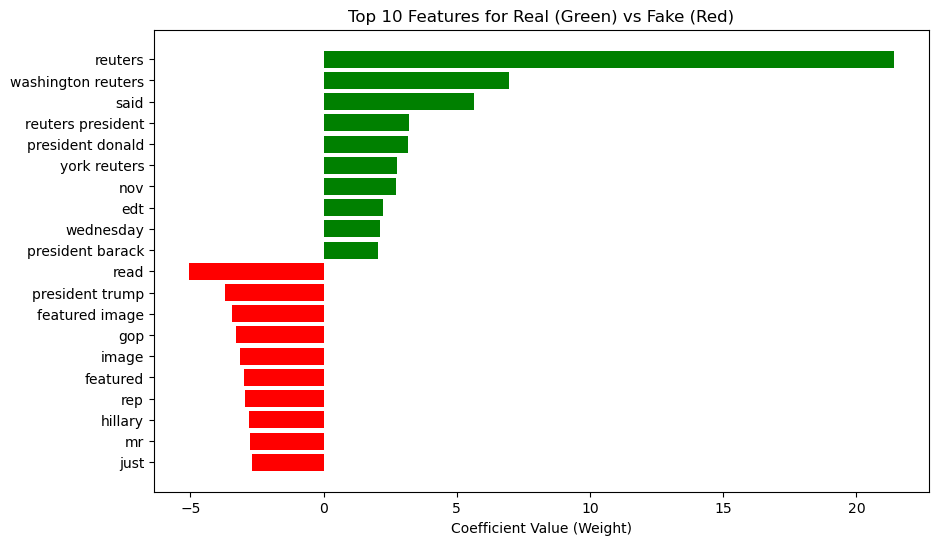

In [50]:
import matplotlib.pyplot as plt

def plot_top_features(vectorizer, model, n_top=10):
    # Get feature names from the vectorizer
    feature_names = vectorizer.get_feature_names_out()
    
    # Get coefficients (for binary classification, it's a single row)
    coefs = model.coef_.toarray()[0]
    
    # Create a DataFrame for easy sorting
    features_df = pd.DataFrame({'word': feature_names, 'coef': coefs})
    
    # Get top 'n' for Real (Positive) and Fake (Negative)
    top_real = features_df.sort_values(by='coef', ascending=False).head(n_top)
    top_fake = features_df.sort_values(by='coef', ascending=True).head(n_top)
    
    # Combine and plot
    top_combined = pd.concat([top_real, top_fake])
    
    plt.figure(figsize=(10, 6))
    colors = ['green' if c > 0 else 'red' for c in top_combined['coef']]
    plt.barh(top_combined['word'], top_combined['coef'], color=colors)
    plt.xlabel("Coefficient Value (Weight)")
    plt.title(f"Top {n_top} Features for Real (Green) vs Fake (Red)")
    plt.gca().invert_yaxis()  # Best features at the top
    plt.show()

plot_top_features(tfidf_vectorizer, svm_model)

In [51]:
def explain_prediction(text, vectorizer, model):
    # 1. Transform text
    vec = vectorizer.transform([clean_text(text)])
    
    # 2. Get word indices present in this text
    feature_index = vec.nonzero()[1]
    feature_names = vectorizer.get_feature_names_out()
    
    # 3. Calculate (TF-IDF value) * (Model Coefficient)
    weights = []
    for i in feature_index:
        word = feature_names[i]
        score = vec[0, i] * model.coef_[0, i]
        weights.append((word, score))
    
    # 4. Sort by impact
    weights = sorted(weights, key=lambda x: x[1], reverse=True)
    
    print(f"Prediction: {'Real' if model.predict(vec)[0] == 1 else 'Fake'}")
    print("\nTop words contributing to 'Real' classification:")
    pprint(weights[:5])
    print("\nTop words contributing to 'Fake' classification:")
    pprint(weights[-5:])

explain_prediction(fake_sample, tfidf_vectorizer, svm_model)

Prediction: Fake

Top words contributing to 'Real' classification:
[('year', np.float64(0.3572511310393784)),
 ('fake news', np.float64(0.06437091859247364)),
 ('media', np.float64(0.06178491432491902)),
 ('new', np.float64(0.058478391772363816)),
 ('happy', np.float64(0.053604804140068386))]

Top words contributing to 'Fake' classification:
[('getty', np.float64(-0.07754974779475365)),
 ('couldn', np.float64(-0.08460590221263233)),
 ('enemies', np.float64(-0.08747332927010196)),
 ('america', np.float64(-0.14814393679969348)),
 ('just', np.float64(-0.193863037607182))]


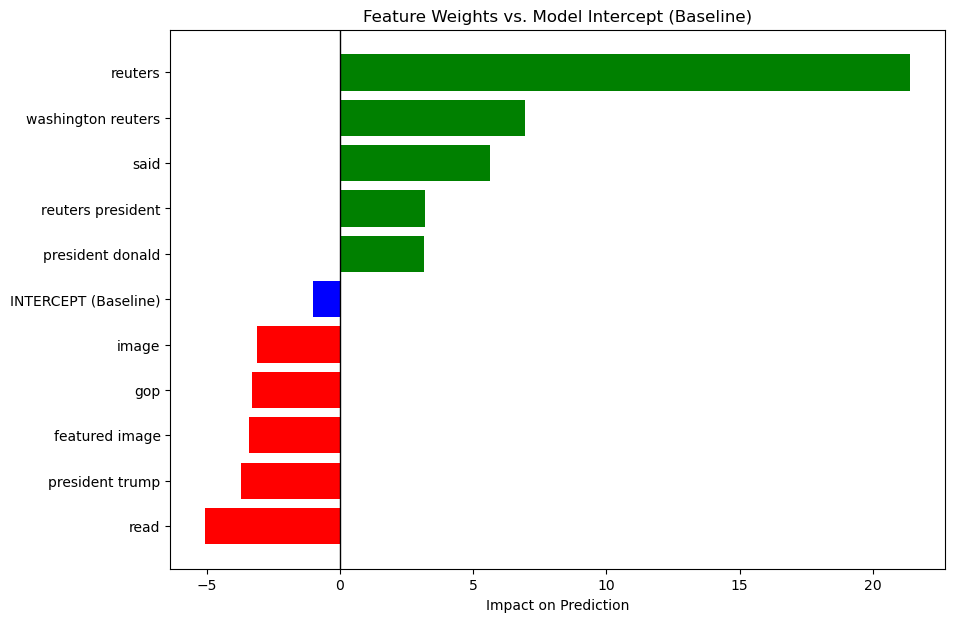

In [52]:
def visualize_with_intercept(vectorizer, model, n_top=5):
    feature_names = vectorizer.get_feature_names_out()
    coefs = model.coef_.toarray()[0]
    
    # Get top 5 positive and top 5 negative
    features_df = pd.DataFrame({'word': feature_names, 'coef': coefs})
    top_features = pd.concat([
        features_df.sort_values(by='coef', ascending=False).head(n_top),
        features_df.sort_values(by='coef', ascending=True).head(n_top)
    ])
    
    # Add intercept to the visualization
    intercept_row = pd.DataFrame({'word': ['INTERCEPT (Baseline)'], 'coef': [model.intercept_[0]]})
    plot_data = pd.concat([intercept_row, top_features]).sort_values(by='coef')

    plt.figure(figsize=(10, 7))
    colors = ['blue' if 'INTERCEPT' in w else ('green' if c > 0 else 'red') for w, c in zip(plot_data['word'], plot_data['coef'])]
    
    plt.barh(plot_data['word'], plot_data['coef'], color=colors)
    plt.axvline(0, color='black', lw=1)
    plt.title("Feature Weights vs. Model Intercept (Baseline)")
    plt.xlabel("Impact on Prediction")
    plt.show()

visualize_with_intercept(tfidf_vectorizer, svm_model)

In [38]:
non_zero_indices = vec_fake.nonzero()[1]

vec_fake[0, non_zero_indices].toarray()

array([[0.03837951, 0.0316401 , 0.07000082, 0.02191145, 0.05086584,
        0.02587586, 0.04262028, 0.04023012, 0.05113264, 0.04429689,
        0.04746005, 0.04070153, 0.05641718, 0.03249048, 0.03329277,
        0.02857433, 0.02619684, 0.02885562, 0.0755101 , 0.04049935,
        0.04821785, 0.45163233, 0.02016955, 0.04315087, 0.04376225,
        0.02860601, 0.04512829, 0.03854139, 0.04845633, 0.04884785,
        0.23565131, 0.05180881, 0.03687246, 0.11096143, 0.12554606,
        0.04260012, 0.07097627, 0.02919513, 0.0294386 , 0.02808444,
        0.08575265, 0.23966625, 0.06950618, 0.10126518, 0.03661233,
        0.04776622, 0.028439  , 0.05078739, 0.03301365, 0.02189687,
        0.02972522, 0.03000302, 0.07187066, 0.03264127, 0.02299805,
        0.03654726, 0.03750068, 0.03254985, 0.03759947, 0.04547732,
        0.03001937, 0.0482059 , 0.03242224, 0.03510856, 0.02088246,
        0.06981106, 0.03166836, 0.04443278, 0.19234694, 0.47317115,
        0.06060723, 0.15099329, 0.05332445, 0.04

In [39]:
non_zero_indices

array([  19,  167,  182,  184,  185,  187,  198,  204,  208,  230,  366,
        521,  693,  750,  773,  817,  898,  948,  983,  993, 1080, 1106,
       1222, 1231, 1243, 1301, 1307, 1309, 1313, 1314, 1442, 1507, 1540,
       1602, 1603, 1755, 1785, 1842, 1843, 1874, 1897, 1956, 1970, 1989,
       1990, 2042, 2129, 2139, 2155, 2158, 2210, 2329, 2371, 2406, 2415,
       2419, 2434, 2485, 2531, 2534, 2559, 2572, 2593, 2600, 2632, 2701,
       2721, 2731, 2923, 2928, 2932, 2935, 3033, 3034, 3177, 3213, 3217,
       3218, 3306, 3328, 3344, 3538, 3558, 3559, 3796, 3833, 3922, 4238,
       4275, 4307, 4364, 4415, 4467, 4496, 4619, 4629, 4631, 4636, 4673,
       4674, 4676, 4678, 4680, 4744, 4819, 4842, 4894, 4928, 4938, 4939,
       4942, 4944, 4967, 4974, 4976, 4977], dtype=int32)

In [ ]:
# use non_zero_indices to get the corresponding feature names with their weights
feature_names = tfidf_vectorizer.get_feature_names_out()
important_features = {feature_names[i]: vec_fake[0, i] for i in non_zero_indices}
# convert to tupple and sort by weight
important_features = sorted(important_features.items(), key=lambda x: x[1], reverse=True)
important_features[:100]  # top 100 important features

[('new year', np.float64(0.4731711462003355)),
 ('december', np.float64(0.4516323311238259)),
 ('year', np.float64(0.27658891763004456)),
 ('happy', np.float64(0.2396662499995962)),
 ('enemies', np.float64(0.23565131316553267)),
 ('wish', np.float64(0.2167860311504392)),
 ('new', np.float64(0.19234693647484852)),
 ('news media', np.float64(0.15099329492504948)),
 ('trump', np.float64(0.13118976766409335)),
 ('fake news', np.float64(0.12554605839592634)),
 ('fake', np.float64(0.1109614296575639)),
 ('healthy', np.float64(0.1012651825755737)),
 ('rapidly', np.float64(0.10096105249679976)),
 ('uses', np.float64(0.09084254667633239)),
 ('stronger', np.float64(0.09078677448999309)),
 ('great', np.float64(0.0857526516730543)),
 ('trump realdonaldtrump', np.float64(0.08122631125284796)),
 ('realdonaldtrump', np.float64(0.07556756472379957)),
 ('couldn', np.float64(0.07551010021394466)),
 ('just', np.float64(0.07187065849526972)),
 ('tweet', np.float64(0.071002749250512)),
 ('friends', np.floa

In [47]:
# do the same thing on svm_weights to find the most important features for classification
svm_weights_array = svm_weights.toarray()[0]
important_svm_features = {feature_names[i]: svm_weights_array[i] for i in range(len(feature_names)) if svm_weights_array[i] != 0}
important_svm_features = sorted(important_svm_features.items(), key=lambda x: x[1], reverse=True)
important_svm_features[:100:-1]  # top 100 important features for SVM classification

[('read', np.float64(-5.050751599426918)),
 ('president trump', np.float64(-3.706498622990722)),
 ('featured image', np.float64(-3.422884105798476)),
 ('gop', np.float64(-3.2993893963325176)),
 ('image', np.float64(-3.12712568457876)),
 ('featured', np.float64(-2.9809745768033595)),
 ('rep', np.float64(-2.9531470422546136)),
 ('hillary', np.float64(-2.792277266704408)),
 ('mr', np.float64(-2.766149928804452)),
 ('just', np.float64(-2.697387802839477)),
 ('getty', np.float64(-2.6562564606284655)),
 ('watch', np.float64(-2.4435265066865384)),
 ('getty images', np.float64(-2.4142700189213024)),
 ('wire', np.float64(-2.279943566998358)),
 ('gov', np.float64(-2.269307662576986)),
 ('sen', np.float64(-2.22804175161511)),
 ('com', np.float64(-2.1613405450026697)),
 ('america', np.float64(-2.1163171499580455)),
 ('president obama', np.float64(-2.0668809012583607)),
 ('doesn', np.float64(-2.0194481581867714)),
 ('terror', np.float64(-1.9613507334253792)),
 ('entire', np.float64(-1.9200590714739

In [48]:
important_svm_features[:100]  # top 100 important features for SVM classification

[('reuters', np.float64(21.396459645438956)),
 ('washington reuters', np.float64(6.962179905041177)),
 ('said', np.float64(5.6342694739728865)),
 ('reuters president', np.float64(3.2017298468673214)),
 ('president donald', np.float64(3.1578719671682096)),
 ('york reuters', np.float64(2.764561336703132)),
 ('nov', np.float64(2.716395791410124)),
 ('edt', np.float64(2.2383635914734703)),
 ('wednesday', np.float64(2.134403752322058)),
 ('president barack', np.float64(2.0442013859504824)),
 ('saying', np.float64(2.033258081183815)),
 ('tuesday', np.float64(2.006905340967069)),
 ('est', np.float64(2.0043397783067793)),
 ('republican', np.float64(1.9461470229434252)),
 ('showed', np.float64(1.9341542021232851)),
 ('reuters republican', np.float64(1.845241897161201)),
 ('comment', np.float64(1.8256598061239)),
 ('rival', np.float64(1.8123324364726159)),
 ('said statement', np.float64(1.6990780603907787)),
 ('washington', np.float64(1.6936509901399643)),
 ('nov election', np.float64(1.69310327

In [ ]:
# clasify samples
svm_pred_fake = svm_model.predict(vec_fake)
svm_pred_true = svm_model.predict(vec_true)



(array([0]), array([1]))